# Análisis de Resultados ML - TMT K

In [1]:
import pandas as pd

df = pd.read_csv("../results/regression/2026-01-26_1901/K_6/tmt_k/summary.csv")
df

,model,r2,mse,mae,y_true,y_pred
0,DummyRegressor,-0.010899,1.154102,0.848730,"[0.6, 2.8, 4.2, 2.2, 3.6, 0.8, 3.6, 1.53, 2.4,...","[2.4007608695652176, 2.388804347826087, 2.3811..."
1,LinearRegression,-0.116319,1.274456,0.917199,"[0.6, 2.8, 4.2, 2.2, 3.6, 0.8, 3.6, 1.53, 2.4,...","[1.9545476470260472, 2.314851872336263, 2.5901..."
2,Ridge,0.027146,1.110667,0.845062,"[0.6, 2.8, 4.2, 2.2, 3.6, 0.8, 3.6, 1.53, 2.4,...","[2.1099312703322104, 2.4299778540403247, 2.723..."
3,Lasso,-0.044597,1.192574,0.869554,"[0.6, 2.8, 4.2, 2.2, 3.6, 0.8, 3.6, 1.53, 2.4,...","[2.4007608695652176, 2.388804347826087, 2.3811..."
4,XGBRegressor,-0.019601,1.164037,0.891576,"[0.6, 2.8, 4.2, 2.2, 3.6, 0.8, 3.6, 1.53, 2.4,...","[1.9128085374832153, 2.0887765884399414, 2.666..."
5,ElasticNet,-0.056747,1.206445,0.889939,"[0.6, 2.8, 4.2, 2.2, 3.6, 0.8, 3.6, 1.53, 2.4,...","[2.4007608695652176, 2.4298125491591804, 2.727..."
6,SVR,-0.011006,1.154224,0.852428,"[0.6, 2.8, 4.2, 2.2, 3.6, 0.8, 3.6, 1.53, 2.4,...","[2.4581882402140853, 2.332919855729474, 2.6258..."
7,RandomForestRegressor,0.012825,1.127017,0.854177,"[0.6, 2.8, 4.2, 2.2, 3.6, 0.8, 3.6, 1.53, 2.4,...","[2.161549279609279, 2.3913718752803907, 2.8049..."


In [6]:
import sys
sys.path.insert(0, '..')

from src.model.datasetbuilder.dataset_builder import DatasetBuilder

# Cargar el dataset usado para los modelos
dataset = 'tmt_k'
builder = DatasetBuilder()
X, y, feature_names, target_name = builder.get_dataset(dataset)

# Crear DataFrame con los features para explorar
df_features = pd.DataFrame(X, columns=feature_names)
df_features['target'] = y

print(f"Dataset: {dataset}")
print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Target: {target_name}")
df_features.head()

Dataset: tmt_k
Samples: 185, Features: 170
Target: K_6


,area_difference_from_ideal_PART_A,area_difference_from_ideal_PART_B,average_duration_PART_A,average_duration_PART_B,correct_targets_touches_PART_A,correct_targets_touches_PART_B,distance_difference_from_ideal_PART_A,distance_difference_from_ideal_PART_B,hesitation_avg_speed_PART_A,hesitation_avg_speed_PART_B,...,travel_avg_speed_PART_B,travel_distance_PART_A,travel_distance_PART_B,travel_time_PART_A,travel_time_PART_B,valid_interval_count_PART_A,valid_interval_count_PART_B,wrong_targets_touches_PART_A,wrong_targets_touches_PART_B,target
0,1248.241760,1796.087299,405.648148,254.833333,10.0,10.0,24.640867,27.778190,0.104522,0.119332,...,0.229479,646.745078,535.078794,2243.666667,2366.500000,758.000000,757.000000,0.0,0.0,0.6
1,2413.761789,1812.318829,228.515133,243.894136,10.0,10.0,30.372466,28.551063,0.230457,0.215996,...,0.427479,582.482537,505.496986,1315.100000,1163.222222,495.600000,728.555556,0.0,0.0,2.8
2,1912.416306,2522.437769,250.837654,427.569841,10.0,10.0,25.773707,37.600730,0.199273,0.165295,...,0.347062,571.831044,441.058361,1491.222222,1237.555556,397.888889,593.111111,0.0,0.0,4.2
3,562.414053,1019.843303,83.178571,153.171429,10.0,10.0,16.217879,15.335298,0.216958,0.225781,...,0.337168,632.437384,774.719988,1759.000000,2284.000000,405.000000,945.500000,0.0,0.0,2.2
4,1689.909682,2211.550752,233.660556,220.447619,10.0,10.0,26.080216,31.505984,0.164402,0.166642,...,0.337950,699.883714,694.794568,2243.400000,2037.500000,456.300000,588.000000,0.0,0.0,3.6


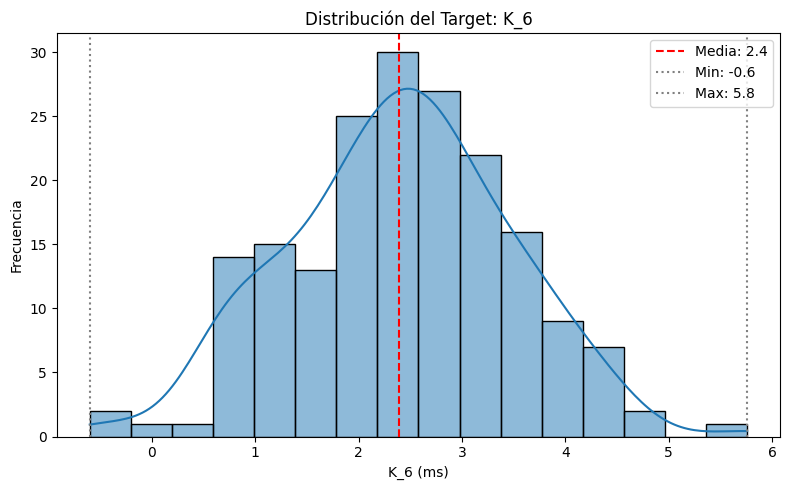

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(y, kde=True, ax=ax)
ax.set_xlabel(f'{target_name} (ms)')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución del Target: {target_name}')
ax.axvline(y.mean(), color='red', linestyle='--', label=f'Media: {y.mean():.1f}')
ax.axvline(y.min(), color='gray', linestyle=':', label=f'Min: {y.min():.1f}')
ax.axvline(y.max(), color='gray', linestyle=':', label=f'Max: {y.max():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

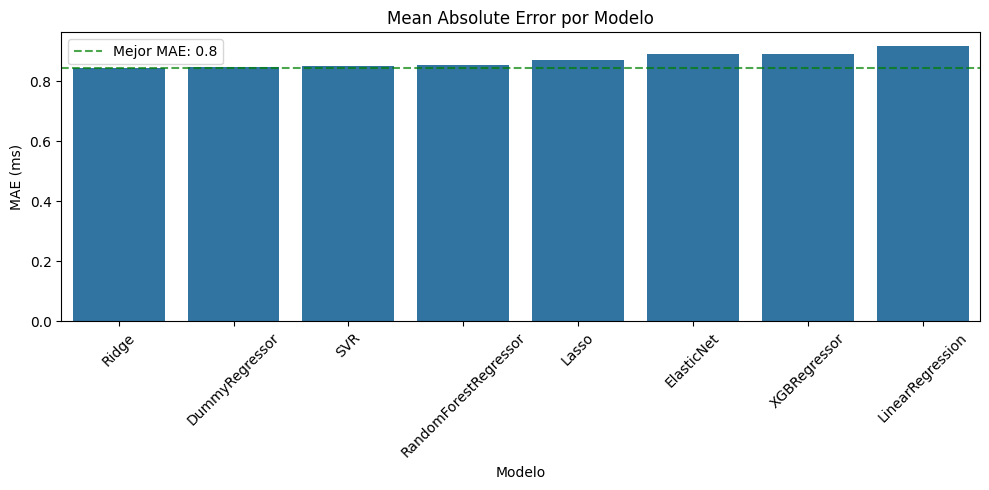

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
df_sorted = df.sort_values('mae')
sns.barplot(data=df_sorted, x='model', y='mae', ax=ax)
ax.set_xlabel('Modelo')
ax.set_ylabel('MAE (ms)')
ax.set_title('Mean Absolute Error por Modelo')
ax.tick_params(axis='x', rotation=45)
ax.axhline(df['mae'].min(), color='green', linestyle='--', alpha=0.7, label=f'Mejor MAE: {df["mae"].min():.1f}')
ax.legend()
plt.tight_layout()
plt.show()